In [1]:
import pickle
import os
import jax
import flax
import tyro
import time
import optax
import wandb
import pickle
import random
import wandb_osh
import numpy as np
import flax.linen as nn
import jax.numpy as jnp
import matplotlib.pyplot as plt

from brax import envs
from etils import epath
from dataclasses import dataclass
from collections import namedtuple
from typing import NamedTuple, Any
from wandb_osh.hooks import TriggerWandbSyncHook
from flax.training.train_state import TrainState
from flax.linen.initializers import variance_scaling
from brax.io import html
from brax.io import model

from evaluator import CrlEvaluator
from buffer import TrajectoryUniformSamplingQueue
from memory_bank import MemoryBank, MemoryBankState

#COPY OVER DEFINITIONS
@dataclass
class Args:
    exp_name: str = "train" # os.path.basename(__file__)[: -len(".py")]
    seed: int = random.randint(1, 1000) # 16
    torch_deterministic: bool = True
    cuda: bool = True
    track: bool = True
    wandb_project_name: str = "clean_JaxGCRL_test"
    wandb_entity: str = 'wang-kevin3290-princeton-university'
    wandb_mode: str = 'offline'
    wandb_dir: str = '.'
    wandb_group: str = '.'
    capture_vis: bool = True
    vis_length: int = 1000
    checkpoint: bool = True

    #environment specific arguments
    env_id: str = "humanoid" # "ant_push" "ant_hardest_maze" "ant_big_maze" "humanoid" "ant"
    episode_length: int = 1000
    # to be filled in runtime
    obs_dim: int = 0
    goal_start_idx: int = 0
    goal_end_idx: int = 0

    # Algorithm specific arguments
    total_env_steps: int = 100000000 # 50000000
    num_epochs: int = 100 # 50
    num_envs: int = 512
    eval_env_id: str = ""
    num_eval_envs: int = 128
    actor_lr: float = 3e-4
    critic_lr: float = 3e-4
    alpha_lr: float = 3e-4
    batch_size: int = 256
    gamma: float = 0.99
    logsumexp_penalty_coeff: float = 0.1
    
    #adding in a batch_size_multiplier argument for critic vs. actor batch size
    critic_batch_size_multiplier: float = 1.0 #this has to be less than or equal to 1
    actor_batch_size_multiplier: float = 1.0 #this has to be less than 1

    max_replay_size: int = 10000
    min_replay_size: int = 1000
    
    unroll_length: int  = 62
    
    # ADDING IN A NETWORK WIDTH ARGUMENT
    same_network_width: int = 0
    network_width: int = 256
    critic_network_width: int = 256
    actor_network_width: int = 256
    actor_depth: int = 4
    critic_depth: int = 4
    actor_skip_connections: int = 0 # 0 for no skip connections, >= 0 means the frequency of skip connections (every X layers)
    critic_skip_connections: int = 0 # 0 for no skip connections, >= 0 means the frequency of skip connections (every X layers)
    
    num_episodes_per_env: int = 1 #the number of episodes to sample from each env when sampling data 
    #(to ensure number of batches is consistent as increase batch_size; for now, just a bandaid fix)
    # should be something like batch_size / 256
    training_steps_multiplier: int = 1 #should have the same effect as num_episodes_per_env, hmmm
    use_all_batches: int = 0 # if 1, use all batches; if 0, use a random subset of batches
    num_sgd_batches_per_training_step: int = 800 # this parameter so as to hold the number of batches constant (no matter batch_size, etc)
    
    mrn: int = 0
    memory_bank: int = 0
    memory_bank_size: int = batch_size # this can be modified too
    
    batchdiv2: int = 0 
    # if 1, freeze gradients for second half of batch
    # if 2, split in half along sa and freeze second half of g (Eysenbach ablation, remember it's forward loss)
    #
    # use batch_size * 2 and split in half and freeze gradients and all that (Eysenbach ablation), does not 
    # TODO: if 2, modifies actor such that it uses the half batch size (isolate for critic ablation)
    # can add 3, 4, etc (if diff between 1 and 2, maybe for batch_size ablation we need to have separate for actor and critic)
    # add more for instead of discarding second half, just freeze gradients for second half so symmetric with first
    
    eval_actor: int = 0
    # if 0, use deterministic actor for evaluation
    # if 1, use stochastic actor for evaluation
    # if 2, sample two actions and take the one with the higher Q value
    # if K >= 2, sample K actions and take the one with the highest Q value
    expl_actor: int = 1
    # if 0, use deterministic actor for exploration/collecting data
    # if 1, use stochastic actor for exploration/collecting data
    # if 2, sample two actions and take the one with the higher Q value
    # if K >= 2, sample K actions and take the one with the highest Q value
    
    entropy_param: float = 0.5
    disable_entropy: int = 0
    
    use_relu: int = 0
    
    resnet: str = "noishmistake4_nodense"
    
    num_render: int = 10
    
    
    
    # to be filled in runtime
    env_steps_per_actor_step : int = 0
    """number of env steps per actor step (computed in runtime)"""
    num_prefill_env_steps : int = 0
    """number of env steps to fill the buffer before starting training (computed in runtime)"""
    num_prefill_actor_steps : int = 0
    """number of actor steps to fill the buffer before starting training (computed in runtime)"""
    num_training_steps_per_epoch : int = 0
    """the number of training steps per epoch(computed in runtime)"""

def make_env(env_id, args):
    print(f"making env with env_id: {env_id}", flush=True)
    if env_id == "reacher":
        from envs.reacher import Reacher
        env = Reacher(
            backend="spring",
        )
        args.obs_dim = 10
        args.goal_start_idx = 4
        args.goal_end_idx = 7
    elif env_id == "pusher":
        from envs.pusher import Pusher
        env = Pusher(
            backend="spring",
        )
        args.obs_dim = 20
        args.goal_start_idx = 10
        args.goal_end_idx = 13
    elif env_id == "ant":
        from envs.ant import Ant
        env = Ant(
            backend="spring",
            exclude_current_positions_from_observation=False,
            terminate_when_unhealthy=True,
        )

        args.obs_dim = 29
        args.goal_start_idx = 0
        args.goal_end_idx = 2

    elif "ant" in env_id and "maze" in env_id: #needed the add the ant check to differentiate with humanoid maze
        if "gen" not in env_id:
            from envs.ant_maze import AntMaze
            env = AntMaze(
                backend="spring",
                exclude_current_positions_from_observation=False,
                terminate_when_unhealthy=True,
                maze_layout_name=env_id[4:]
            )

            # args.obs_dim = 29
            # args.goal_start_idx = 0
            # args.goal_end_idx = 2
        else:
            from envs.ant_maze_generalization import AntMazeGeneralization
            gen_idx = env_id.find("gen")
            maze_layout_name = env_id[4:gen_idx-1]
            generalization_config = env_id[gen_idx+4:]
            print(f"maze_layout_name: {maze_layout_name}, generalization_config: {generalization_config}", flush=True)
            env = AntMazeGeneralization(
                backend="spring",
                exclude_current_positions_from_observation=False,
                terminate_when_unhealthy=True,
                maze_layout_name=maze_layout_name,
                generalization_config=generalization_config
            )

            args.obs_dim = 29
            args.goal_start_idx = 0
            args.goal_end_idx = 2
    
    elif env_id == "ant_ball":
        from envs.ant_ball import AntBall
        env = AntBall(
            backend="spring",
            exclude_current_positions_from_observation=False,
            terminate_when_unhealthy=True,
        )

        args.obs_dim = 31
        args.goal_start_idx = 28
        args.goal_end_idx = 30

    elif env_id == "ant_push":
        from envs.ant_push import AntPush
        env = AntPush(
            backend="mjx",
        )

        args.obs_dim = 31
        args.goal_start_idx = 0
        args.goal_end_idx = 2
        
    elif env_id == "humanoid":
        from envs.humanoid import Humanoid
        env = Humanoid(
            backend="spring",
            exclude_current_positions_from_observation=False,
            terminate_when_unhealthy=True,
        )

        args.obs_dim = 268
        args.goal_start_idx = 0
        args.goal_end_idx = 3
        
    elif "humanoid" in env_id and "maze" in env_id:
        from envs.humanoid_maze import HumanoidMaze
        env = HumanoidMaze(
            backend="spring",
            maze_layout_name=env_id[9:]
        )

        args.obs_dim = 268
        args.goal_start_idx = 0
        args.goal_end_idx = 3

        
    elif env_id == "arm_reach":
        from envs.manipulation.arm_reach import ArmReach
        env = ArmReach(
            backend="mjx",
        )

        args.obs_dim = 13
        args.goal_start_idx = 7
        args.goal_end_idx = 10
        
    elif env_id == "arm_binpick_easy":
        from envs.manipulation.arm_binpick_easy import ArmBinpickEasy
        env = ArmBinpickEasy(
            backend="mjx",
        )

        args.obs_dim = 17
        args.goal_start_idx = 0
        args.goal_end_idx = 3
        
    elif env_id == "arm_binpick_hard":
        from envs.manipulation.arm_binpick_hard import ArmBinpickHard
        env = ArmBinpickHard(
            backend="mjx",
        )

        args.obs_dim = 17
        args.goal_start_idx = 0
        args.goal_end_idx = 3
        
    elif env_id == "arm_binpick_easy_EEF":
        from envs.manipulation.arm_binpick_easy_EEF import ArmBinpickEasyEEF
        env = ArmBinpickEasyEEF(
            backend="mjx",
        )

        args.obs_dim = 11
        args.goal_start_idx = 0
        args.goal_end_idx = 3
    
    elif "arm_grasp" in env_id: # either arm_grasp or arm_grasp_0.5, etc
        from envs.manipulation.arm_grasp import ArmGrasp
        cube_noise_scale = float(env_id[10:]) if len(env_id) > 9 else 0.3
        env = ArmGrasp(
            cube_noise_scale=cube_noise_scale,
            backend="mjx",
        )

        args.obs_dim = 23
        args.goal_start_idx = 16
        args.goal_end_idx = 23
    
    elif env_id == "arm_push_easy":
        from envs.manipulation.arm_push_easy import ArmPushEasy
        env = ArmPushEasy(
            backend="mjx",
        )

        args.obs_dim = 17
        args.goal_start_idx = 0
        args.goal_end_idx = 3
    
    elif env_id == "arm_push_hard":
        from envs.manipulation.arm_push_hard import ArmPushHard
        env = ArmPushHard(
            backend="mjx",
        )

        args.obs_dim = 17
        args.goal_start_idx = 0
        args.goal_end_idx = 3

    else:
        raise NotImplementedError
    
    return env

lecun_unfirom = variance_scaling(1/3, "fan_in", "uniform")
bias_init = nn.initializers.zeros
def residual_block(x, width, normalize, activation):
    identity = x
    x = nn.Dense(width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
    x = normalize(x)
    x = activation(x)
    x = nn.Dense(width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
    x = normalize(x)
    x = activation(x)
    x = nn.Dense(width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
    x = normalize(x)
    x = activation(x)
    x = nn.Dense(width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
    x = normalize(x)
    x = activation(x)
    x = x + identity
    return x

class SA_encoder(nn.Module):
    norm_type = "layer_norm"
    network_width: int = 1024
    network_depth: int = 4
    skip_connections: int = 0
    use_relu: int = 0
    @nn.compact
    def __call__(self, s: jnp.ndarray, a: jnp.ndarray):

        lecun_unfirom = variance_scaling(1/3, "fan_in", "uniform")
        bias_init = nn.initializers.zeros
        
        if self.norm_type == "layer_norm":
            normalize = lambda x: nn.LayerNorm()(x)
        else:
            normalize = lambda x: x
        
        if self.use_relu:
            activation = nn.relu
        else:
            activation = nn.swish
            
        x = jnp.concatenate([s, a], axis=-1)
        #Initial layer
        x = nn.Dense(self.network_width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        x = normalize(x)
        x = activation(x)
        #Residual blocks
        for i in range(self.network_depth // 4):
            x = residual_block(x, self.network_width, normalize, activation)
        #Final layer
        x = nn.Dense(64, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        return x
    
class G_encoder(nn.Module):
    norm_type = "layer_norm"
    network_width: int = 1024
    network_depth: int = 4
    skip_connections: int = 0
    use_relu: int = 0
    @nn.compact
    def __call__(self, g: jnp.ndarray):

        lecun_unfirom = variance_scaling(1/3, "fan_in", "uniform")
        bias_init = nn.initializers.zeros

        if self.norm_type == "layer_norm":
            normalize = lambda x: nn.LayerNorm()(x)
        else:
            normalize = lambda x: x
        
        if self.use_relu:
            activation = nn.relu
        else:
            activation = nn.swish
        
        x = g
        #Initial layer
        x = nn.Dense(self.network_width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        x = normalize(x)
        x = activation(x)
        #Residual blocks
        for i in range(self.network_depth // 4):
            x = residual_block(x, self.network_width, normalize, activation)
        #Final layer
        x = nn.Dense(64, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        return x

class Actor(nn.Module):
    action_size: int
    norm_type = "layer_norm"
    network_width: int = 1024
    network_depth: int = 4
    skip_connections: int = 0 # 0 for no skip connections, >= 0 means the frequency of skip connections (every X layers)
    use_relu: int = 0
    LOG_STD_MAX = 2
    LOG_STD_MIN = -5

    @nn.compact
    def __call__(self, x):
        if self.norm_type == "layer_norm":
            normalize = lambda x: nn.LayerNorm()(x)
        else:
            normalize = lambda x: x
            
        if self.use_relu:
            activation = nn.relu
        else:
            activation = nn.swish

        lecun_unfirom = variance_scaling(1/3, "fan_in", "uniform")
        bias_init = nn.initializers.zeros
        
        #Initial layer
        x = nn.Dense(self.network_width, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        x = normalize(x)
        x = activation(x)
        #Residual blocks
        for i in range(self.network_depth // 4):
            x = residual_block(x, self.network_width, normalize, activation)
        #Final layer
        # x = nn.Dense(64, kernel_init=lecun_unfirom, bias_init=bias_init)(x)

        mean = nn.Dense(self.action_size, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        log_std = nn.Dense(self.action_size, kernel_init=lecun_unfirom, bias_init=bias_init)(x)
        
        log_std = nn.tanh(log_std)
        log_std = self.LOG_STD_MIN + 0.5 * (self.LOG_STD_MAX - self.LOG_STD_MIN) * (log_std + 1)  # From SpinUp / Denis Yarats

        return mean, log_std

In [2]:
def create_dataset(run_dir, num_trajs):
    args_path = f"{run_dir}/args.pkl"
    params_path = f"{run_dir}/final.pkl"
    
    eval_env_id = None #if you want to use the env_id in args.eval_env_id, leave this as None
    
    import pickle
    with open(args_path, 'rb') as f:
        args = pickle.load(f)
    
    if eval_env_id:
        env = make_env(eval_env_id, None)
    else:
        env = make_env(args.eval_env_id, args)
    
    obs_size = env.observation_size
    action_size = env.action_size
    
    params = model.load_params(params_path)
    alpha_params, actor_params, critic_params = params
    sa_encoder_params, g_encoder_params = critic_params['sa_encoder'], critic_params['g_encoder']
    actor = Actor(action_size=action_size, network_width=args.actor_network_width, network_depth=args.actor_depth, skip_connections=args.actor_skip_connections, use_relu=args.use_relu)
    sa_encoder = SA_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)
    g_encoder = G_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)
    
    NUM_TRAJS = num_trajs
    
    states_dataset = np.zeros((1000 * NUM_TRAJS, obs_size))
    actions_dataset = np.zeros((1000 * NUM_TRAJS, action_size))
    
    #COLLECT ONE TRAJECTORY

    SEED = 4237
    # Initialize environment
    rng = jax.random.PRNGKey(seed=SEED)
    # env_state = jax.jit(env.reset)(rng)
    
    @jax.jit
    def collect_trajectory(actor_params, rng, steps=1000):
        rng, reset_rng = jax.random.split(rng)
        init_state = jax.jit(env.reset)(reset_rng)
    
        @jax.jit
        def policy_step(env_state, actor_params):
            means, _ = actor.apply(actor_params, env_state.obs)
            actions = nn.tanh(means)
            return actions
        
        @jax.jit
        def step(env_state, action, rng):
            next_state = env.step(env_state, action)
            return next_state, next_state
    
        
        def body_fn(i, carry):
            env_state, states, actions, rng = carry
            rng, step_rng = jax.random.split(rng)
            
            # Get action from policy
            action = policy_step(env_state, actor_params)
            
            # Step environment forward
            next_state, _ = step(env_state, action, step_rng)
            
            # Store state and action
            states = states.at[i].set(env_state.obs)
            actions = actions.at[i].set(action)
            
            return next_state, states, actions, rng
        
        # Initialize arrays to store trajectory
        states = jnp.zeros((steps, env.observation_size))
        actions = jnp.zeros((steps, env.action_size))
        
        # Collect trajectory
        final_state, states, actions, _ = jax.lax.fori_loop(
            0, steps, body_fn, (init_state, states, actions, rng)
        )
        
        return states, actions
        
    for i in range(NUM_TRAJS):
        rng, trajectory_rng = jax.random.split(rng)
        states, actions = collect_trajectory(actor_params, trajectory_rng)
        states_dataset[i*1000:(i+1)*1000] = states
        actions_dataset[i*1000:(i+1)*1000] = actions
    
    return states_dataset, actions_dataset, args.actor_depth

In [9]:
run_dirs = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051",  # Humanoid, depth 64 (100k)
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_406_20250117-061340",  # Humanoid, depth 64 (#2)
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_886_20250117-061455",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_550_20250105-180444",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_271_20250117-071637", #depth 8
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_186_20250105-180537", #depth 32
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_594_20250117-065555", #depth 16
]
num_trajs = 30
for run_dir in run_dirs:
    states_dataset, actions_dataset, depth = create_dataset(run_dir, num_trajs)
    import pickle
    seed = run_dir.split('_')[-2]
    dataset_fname = f'trajs_datasets/trajs_dataset_depth:{depth}_seed:{seed}_{len(states_dataset)}'
    with open(dataset_fname, 'wb') as f:
        data = (states_dataset, actions_dataset, depth)
        pickle.dump(data, f)

making env with env_id: humanoid


In [38]:
def sa_embeddings(model_dir, dataset_fname, single_traj=False, plot=True):
    run_dir = model_dir
    args_path = f"{run_dir}/args.pkl"
    params_path = f"{run_dir}/final.pkl"
    
    eval_env_id = None #if you want to use the env_id in args.eval_env_id, leave this as None
    
    import pickle
    with open(args_path, 'rb') as f:
        args = pickle.load(f)
    
    if eval_env_id:
        env = make_env(eval_env_id, None)
    else:
        env = make_env(args.eval_env_id, args)
    
    obs_size = env.observation_size
    action_size = env.action_size
    
    params = model.load_params(params_path)
    alpha_params, actor_params, critic_params = params
    sa_encoder_params, g_encoder_params = critic_params['sa_encoder'], critic_params['g_encoder']
    actor = Actor(action_size=action_size, network_width=args.actor_network_width, network_depth=args.actor_depth, skip_connections=args.actor_skip_connections, use_relu=args.use_relu)
    sa_encoder = SA_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)
    g_encoder = G_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)

    goal_size = g_encoder_params["params"]["Dense_0"]["kernel"].shape[0]
    # Encode (state, action) pairs with sa_encoder
    def encode_sa_pairs(states, actions, sa_encoder, sa_encoder_params, goal_size):
        # Strip away the goal part from states
        states_no_goal = states[:, :-goal_size] if goal_size > 0 else states
        
        # Use vmap to encode each (state, action) pair
        encodings = jax.vmap(lambda s, a: sa_encoder.apply(sa_encoder_params, s, a))(states_no_goal, actions)
        
        return encodings

    with open(dataset_fname, 'rb') as f:
        states_dataset, actions_dataset, dataset_depth = pickle.load(f)
        dataset_seed = dataset_fname.split(':')[-1].split('_')[0]
    model_depth = args.actor_depth
    model_seed = run_dir.split('_')[-2]

    if single_traj:
        states_dataset = states_dataset[:1000, :]
        actions_dataset = actions_dataset[:1000, :]
    
    # Get the encodings
    encodings = encode_sa_pairs(states_dataset, actions_dataset, sa_encoder, sa_encoder_params, goal_size)
    encodings_np = np.array(encodings)
    
    # Project encodings to 3D
    from sklearn.decomposition import PCA
    pca = PCA(n_components=3)
    projection = pca.fit_transform(encodings_np)

    if plot:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        time_steps = np.linspace(0, 1, len(projection))
        
        for i in range(len(projection) - 1):
            ax.plot(projection[i:i+2, 0], projection[i:i+2, 1], projection[i:i+2, 2], 
                    linewidth=2, marker='.', linestyle='-')
        
        ax.set_xlabel('PCA Dim 1')
        ax.set_ylabel('PCA Dim 2')
        ax.set_zlabel('PCA Dim 3')
        ax.set_title(f'Embeddings of (s, a) by [Depth={model_depth}, Seed={model_seed}] on dataset generated by [Depth={dataset_depth}, Seed={dataset_seed}]')
        ax.legend()
        
        plt.tight_layout()
        plt.show()

    return encodings_np, (dataset_depth, dataset_seed, model_depth, model_seed)

In [65]:
def g_embeddings(model_dir, dataset_fname, single_traj=False, plot=True):
    run_dir = model_dir
    args_path = f"{run_dir}/args.pkl"
    params_path = f"{run_dir}/final.pkl"
    
    eval_env_id = None #if you want to use the env_id in args.eval_env_id, leave this as None
    
    import pickle
    with open(args_path, 'rb') as f:
        args = pickle.load(f)
    
    if eval_env_id:
        env = make_env(eval_env_id, None)
    else:
        env = make_env(args.eval_env_id, args)
    
    obs_size = env.observation_size
    action_size = env.action_size
    
    params = model.load_params(params_path)
    alpha_params, actor_params, critic_params = params
    sa_encoder_params, g_encoder_params = critic_params['sa_encoder'], critic_params['g_encoder']
    actor = Actor(action_size=action_size, network_width=args.actor_network_width, network_depth=args.actor_depth, skip_connections=args.actor_skip_connections, use_relu=args.use_relu)
    sa_encoder = SA_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)
    g_encoder = G_encoder(network_width=args.critic_network_width, network_depth=args.critic_depth, skip_connections=args.critic_skip_connections, use_relu=args.use_relu)

    goal_size = g_encoder_params["params"]["Dense_0"]["kernel"].shape[0]
    # Encode (state, action) pairs with sa_encoder
    def encode_g_pairs(states, actions, g_encoder, g_encoder_params, goal_size):
        # Strip away the goal part from states
        states_goal = states[:, :goal_size] if goal_size > 0 else states
        
        # Use vmap to encode each (state, action) pair
        encodings = jax.vmap(lambda g: g_encoder.apply(g_encoder_params, g))(states_goal)
        
        return encodings

    with open(dataset_fname, 'rb') as f:
        states_dataset, actions_dataset, dataset_depth = pickle.load(f)
        dataset_seed = dataset_fname.split(':')[-1].split('_')[0]
    model_depth = args.actor_depth
    model_seed = run_dir.split('_')[-2]

    if single_traj:
        states_dataset = states_dataset[:1000, :]
        actions_dataset = actions_dataset[:1000, :]
    
    # Get the encodings
    encodings = encode_g_pairs(states_dataset, actions_dataset, g_encoder, g_encoder_params, goal_size)
    encodings_np = np.array(encodings)
    
    # Project encodings to 3D
    from sklearn.decomposition import PCA
    pca = PCA(n_components=3)
    projection = pca.fit_transform(encodings_np)

    if plot:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        time_steps = np.linspace(0, 1, len(projection))
        
        for i in range(len(projection) - 1):
            ax.plot(projection[i:i+2, 0], projection[i:i+2, 1], projection[i:i+2, 2], 
                    linewidth=2, marker='.', linestyle='-')
        
        ax.set_xlabel('PCA Dim 1')
        ax.set_ylabel('PCA Dim 2')
        ax.set_zlabel('PCA Dim 3')
        ax.set_title(f'Embeddings of g by [Depth={model_depth}, Seed={model_seed}] on dataset generated by [Depth={dataset_depth}, Seed={dataset_seed}]')
        ax.legend()
        
        plt.tight_layout()
        plt.show()

    return encodings_np, (dataset_depth, dataset_seed, model_depth, model_seed)

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/home/kw6487/.conda/envs/expl-env-jupyter2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


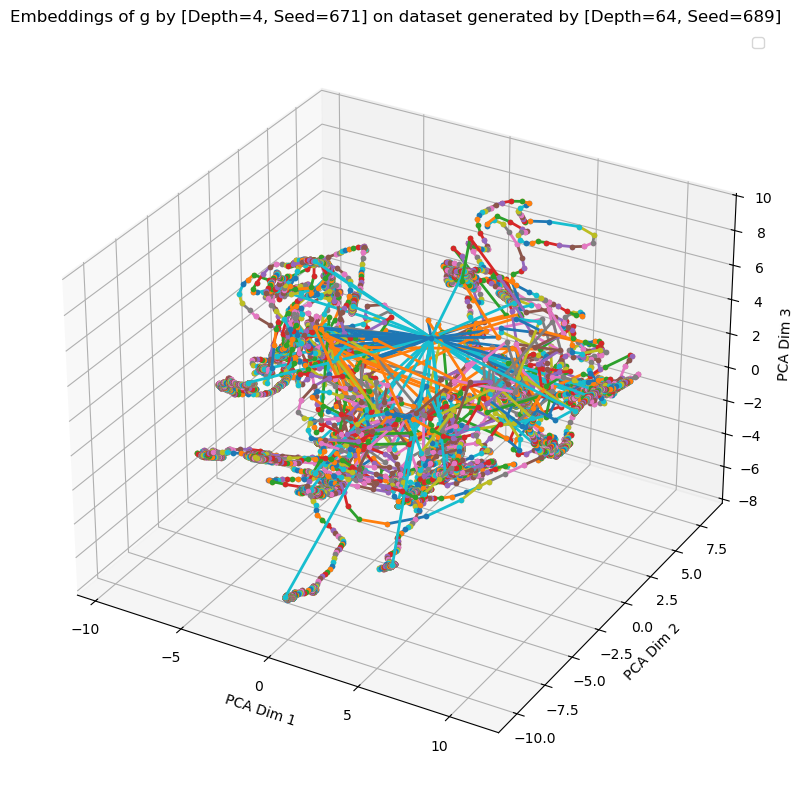

In [66]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659" #depth 4
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
x = g_embeddings(model_dir, dataset_fname)

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


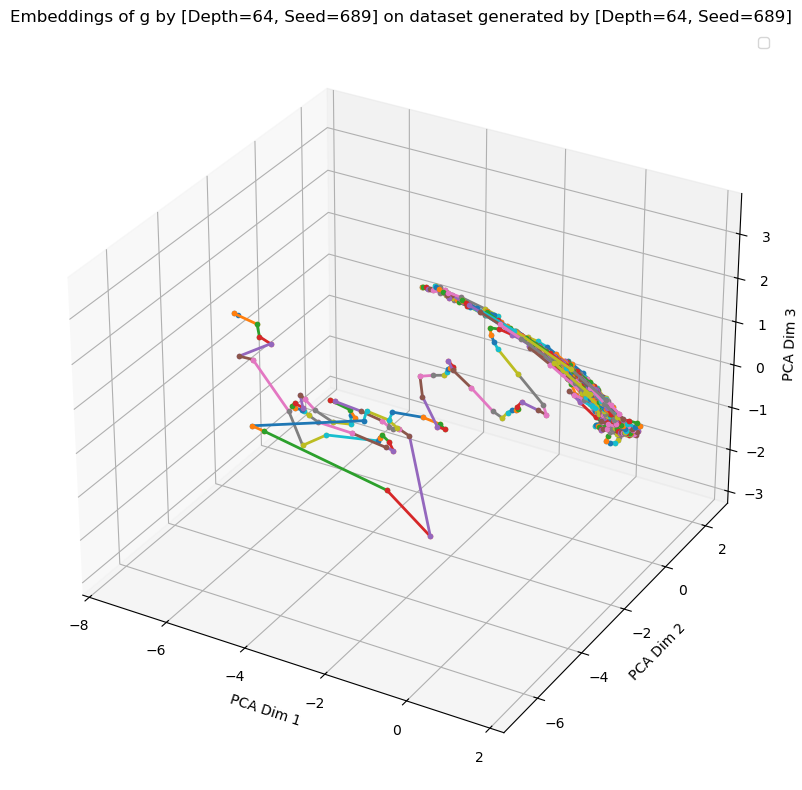

In [82]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410" 
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
x = g_embeddings(model_dir, dataset_fname, single_traj=True)

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


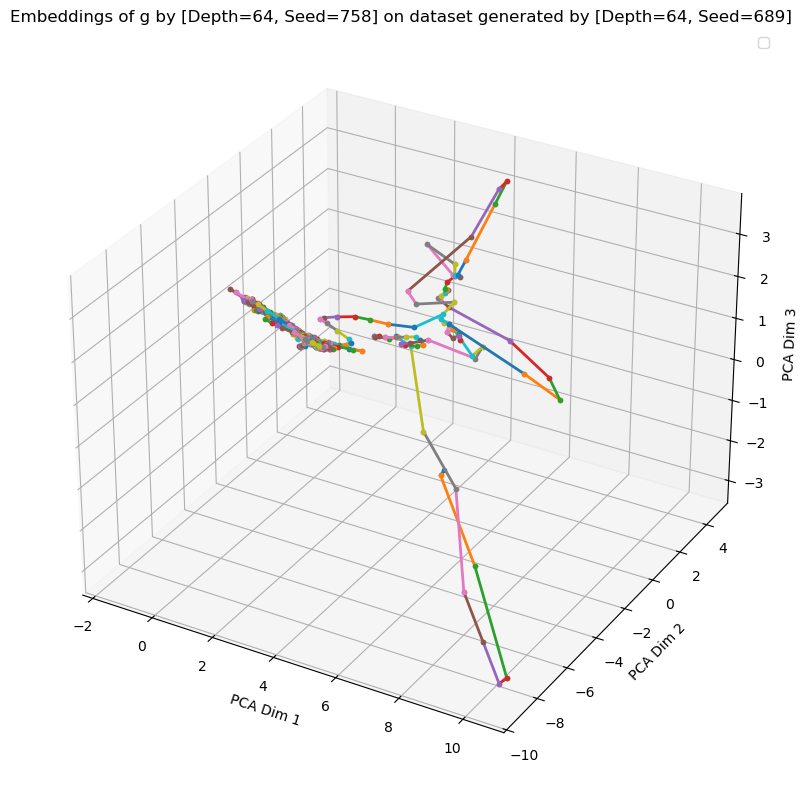

In [81]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051" 
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
x = g_embeddings(model_dir, dataset_fname, single_traj=True)

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


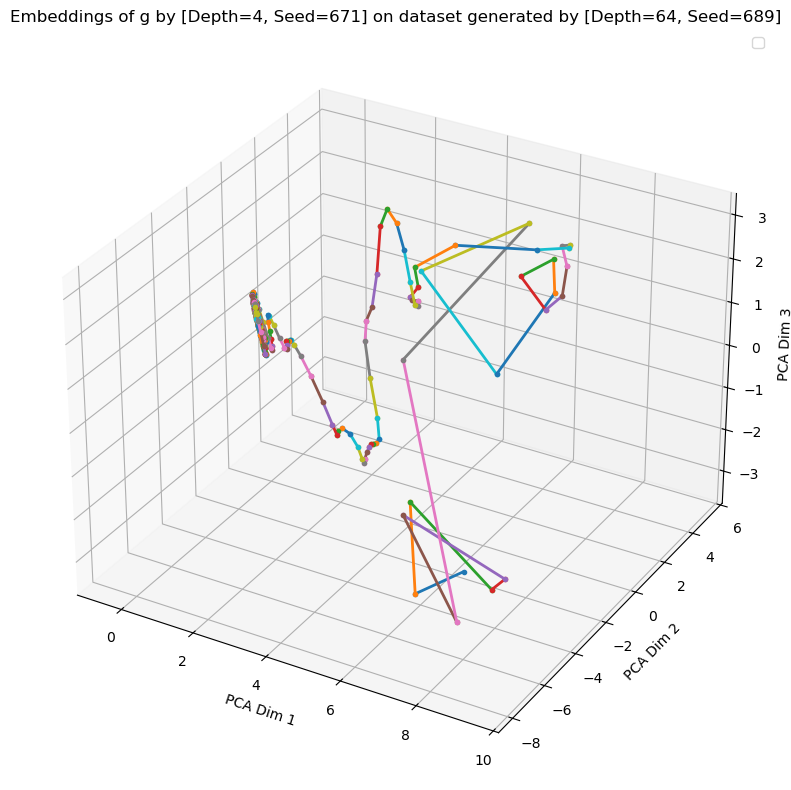

In [80]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659" 
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
x = g_embeddings(model_dir, dataset_fname, single_traj=True)

In [84]:
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"

model_dirs = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659", #depth 4
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_271_20250117-071637", #depth 8
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_594_20250117-065555", #depth 16
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_186_20250105-180537", #depth 32
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051", #depth 64 (off policy)
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410", #depth 64 (on policy)
]

swds = []
for model_dir in model_dirs:
    encodings, (dataset_depth, dataset_seed, model_depth, model_seed) = g_embeddings(model_dir, dataset_fname, plot=False)
    swd = sliced_wasserstein_distance(
        encodings,
        n_projections=1024,
        assume_unit_norm=False,   # set False if they’re *not* L2‑normalised
        seed=42
    )
    print(f"Sliced‑Wasserstein distance to N(0,I): {swd:.4f}")
    swds.append((swd, (dataset_depth, dataset_seed, model_depth, model_seed)))

making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.3655
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4374
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4623
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4107
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4817
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.5230


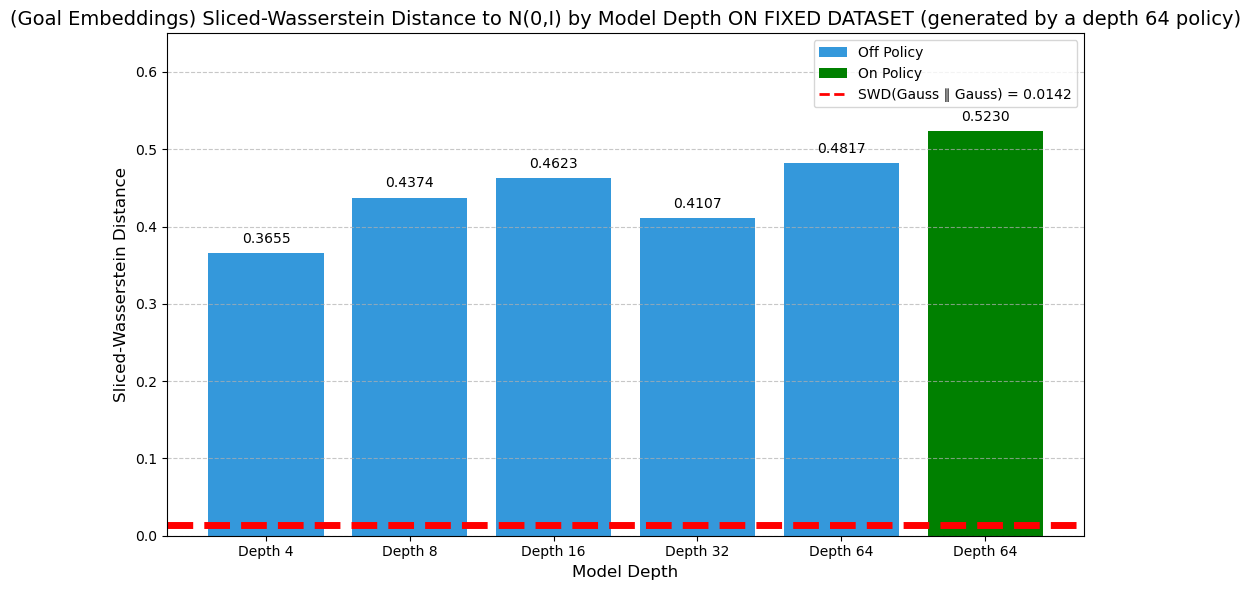

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your code
model_depths = [4, 8, 16, 32, 64, 64]
model_types = ["off policy" if i != 5 else "on policy" for i in range(6)]
# Replace these values with your actual SWD values
# Since I don't have the actual SWD values from your run, I'm using placeholders
# You should replace these with the actual values from your swds list
swd_values = [s[0] for s in swds]  # Placeholder values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.8

# Set positions of bars on x-axis
bar_positions = np.arange(len(model_depths))

# Create color scheme - different color for on-policy vs off-policy
colors = ['#3498db' if model_type == "off policy" else 'green' 
          for model_type in model_types]

# Create bars
bars = ax.bar(bar_positions, swd_values, width=bar_width, color=colors)

# Create x-axis labels
x_labels = [f"Depth {depth}" for i, depth in enumerate(model_depths)]
ax.set_xticks(bar_positions)
ax.set_xticklabels(x_labels)

# Add labels and title
ax.set_xlabel('Model Depth', fontsize=12)
ax.set_ylabel('Sliced-Wasserstein Distance', fontsize=12)
ax.set_title('(Goal Embeddings) Sliced-Wasserstein Distance to N(0,I) by Model Depth ON FIXED DATASET (generated by a depth 64 policy)', fontsize=14)
ax.set_ylim(None, 0.65)

# Add a horizontal grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add reference line for SWD(Gauss ∥ Gauss)
reference_value = 0.0142
ax.axhline(y=reference_value, color='red', linestyle='--', linewidth=5)

# Add a legend with reference line included
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#3498db', label='Off Policy'),
    Patch(facecolor='green', label='On Policy'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='SWD(Gauss ∥ Gauss) = 0.0142')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add value labels on top of each bar
for bar, value in zip(bars, swd_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# If you want to save the figure
# plt.savefig("swd_barplot.png", dpi=300, bbox_inches='tight')

In [88]:
#NOW SWD ON POLICY
# dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"

model_dirs = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659", #depth 4
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_271_20250117-071637", #depth 8
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_594_20250117-065555", #depth 16
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_186_20250105-180537", #depth 32
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051", #depth 64 (off policy)
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410", #depth 64 (on policy)
]

dataset_fnames = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:4_seed:671_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:8_seed:271_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:16_seed:594_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:32_seed:186_30000",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:758_30000"
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
]


swds = []
for model_dir, dataset_fname in zip(model_dirs, dataset_fnames):
    encodings, (dataset_depth, dataset_seed, model_depth, model_seed) = g_embeddings(model_dir, dataset_fname, plot=False)
    swd = sliced_wasserstein_distance(
        encodings,
        n_projections=1024,
        assume_unit_norm=False,   # set False if they’re *not* L2‑normalised
        seed=42
    )
    print(f"Sliced‑Wasserstein distance to N(0,I): {swd:.4f}")
    swds.append((swd, (dataset_depth, dataset_seed, model_depth, model_seed)))

making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.3631
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4468
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4689
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4046
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.5230


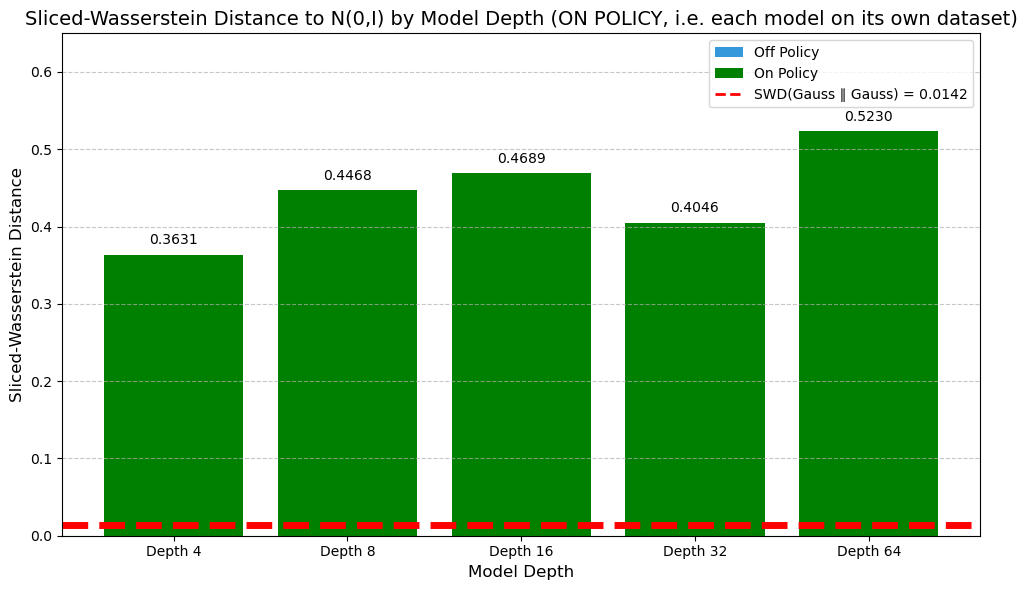

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your code
model_depths = [4, 8, 16, 32, 64]
model_types = ["on policy" for i in range(5)]
# Replace these values with your actual SWD values
# Since I don't have the actual SWD values from your run, I'm using placeholders
# You should replace these with the actual values from your swds list
swd_values = [s[0] for s in swds]  # Placeholder values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.8

# Set positions of bars on x-axis
bar_positions = np.arange(len(model_depths))

# Create color scheme - different color for on-policy vs off-policy
colors = ['#3498db' if model_type == "off policy" else 'green' 
          for model_type in model_types]

# Create bars
bars = ax.bar(bar_positions, swd_values, width=bar_width, color=colors)

# Create x-axis labels
x_labels = [f"Depth {depth}" for i, depth in enumerate(model_depths)]
ax.set_xticks(bar_positions)
ax.set_xticklabels(x_labels)

# Add labels and title
ax.set_xlabel('Model Depth', fontsize=12)
ax.set_ylabel('Sliced-Wasserstein Distance', fontsize=12)
ax.set_title('Sliced-Wasserstein Distance to N(0,I) by Model Depth (ON POLICY, i.e. each model on its own dataset)', fontsize=14)
ax.set_ylim(None, 0.65)

# Add a horizontal grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add reference line for SWD(Gauss ∥ Gauss)
reference_value = 0.0142
ax.axhline(y=reference_value, color='red', linestyle='--', linewidth=5)

# Add a legend with reference line included
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#3498db', label='Off Policy'),
    Patch(facecolor='green', label='On Policy'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='SWD(Gauss ∥ Gauss) = 0.0142')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add value labels on top of each bar
for bar, value in zip(bars, swd_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# If you want to save the figure
# plt.savefig("swd_barplot.png", dpi=300, bbox_inches='tight')

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


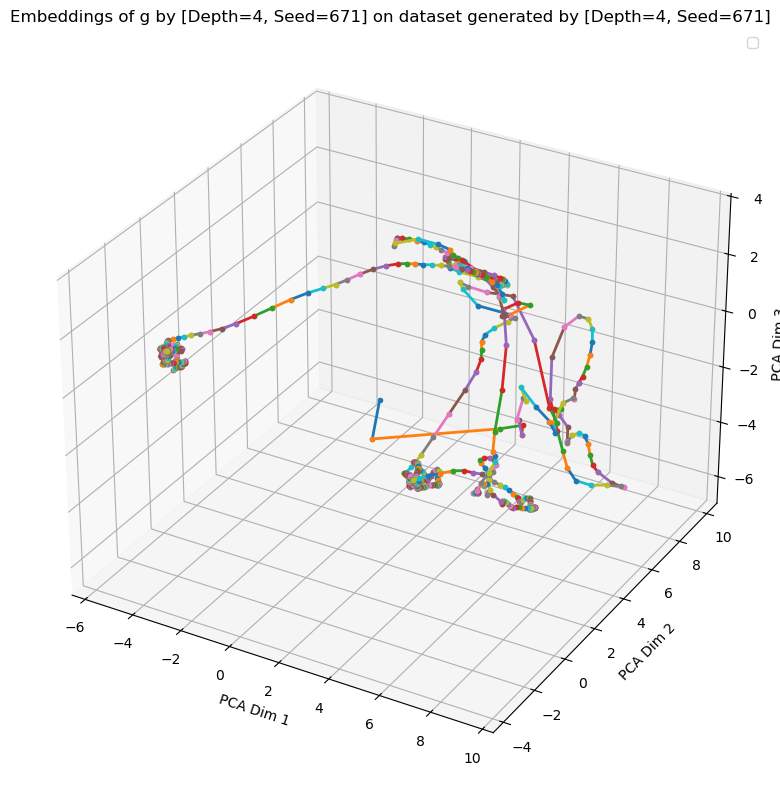

In [67]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659" #depth 4
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:4_seed:671_30000"
x = g_embeddings(model_dir, dataset_fname, single_traj=True)

making env with env_id: humanoid


/tmp/ipykernel_421772/2719006732.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


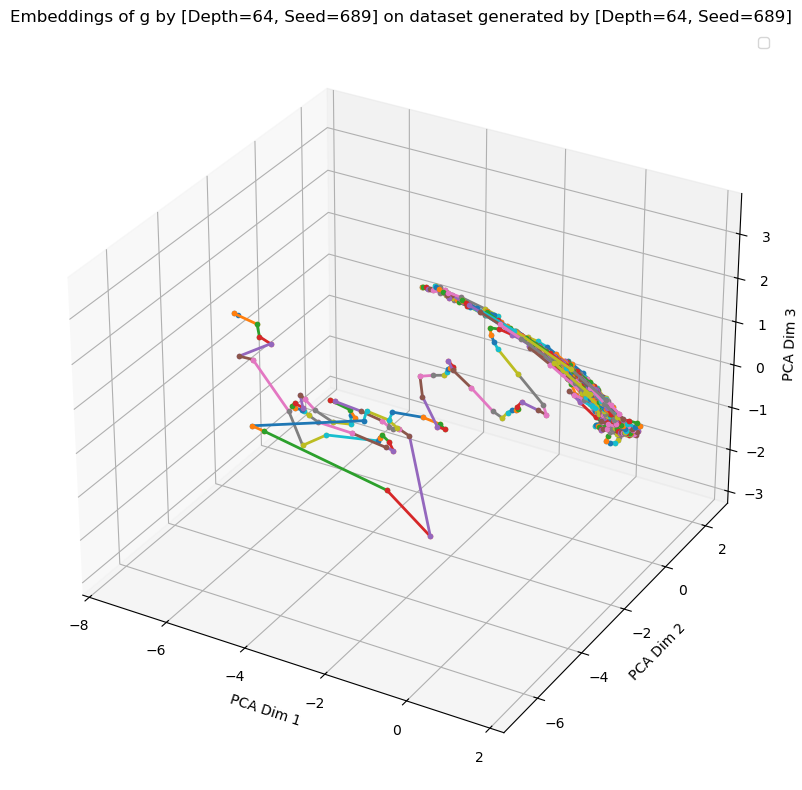

In [83]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410" 
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
x = g_embeddings(model_dir, dataset_fname, single_traj=True)

making env with env_id: humanoid


/tmp/ipykernel_421772/525012663.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


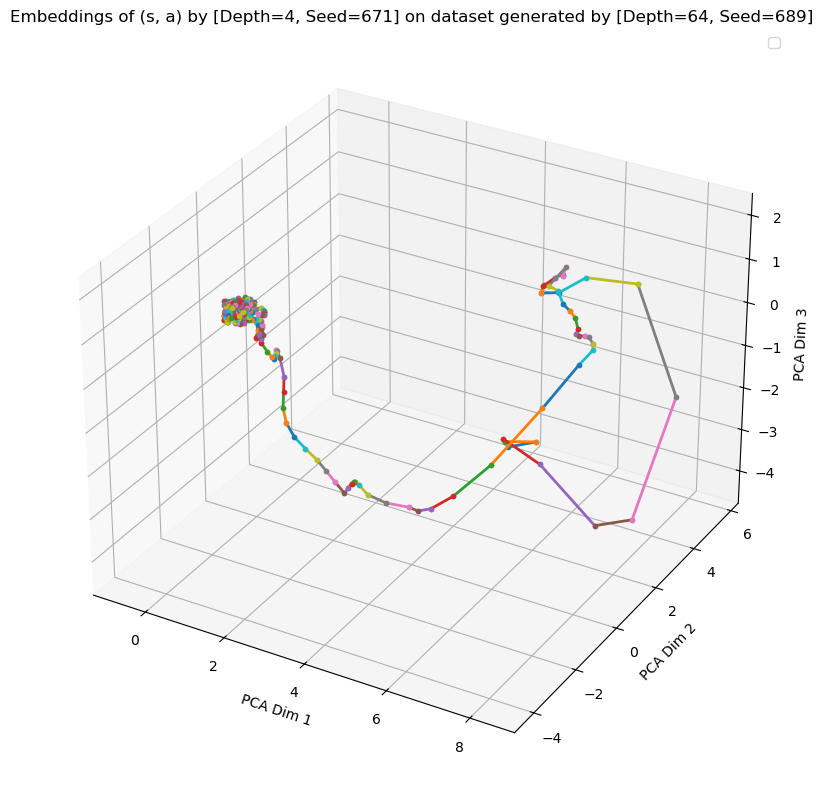

In [18]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659" #depth 4
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
sa_embeddings(model_dir, dataset_fname)

making env with env_id: humanoid


/tmp/ipykernel_421772/525012663.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


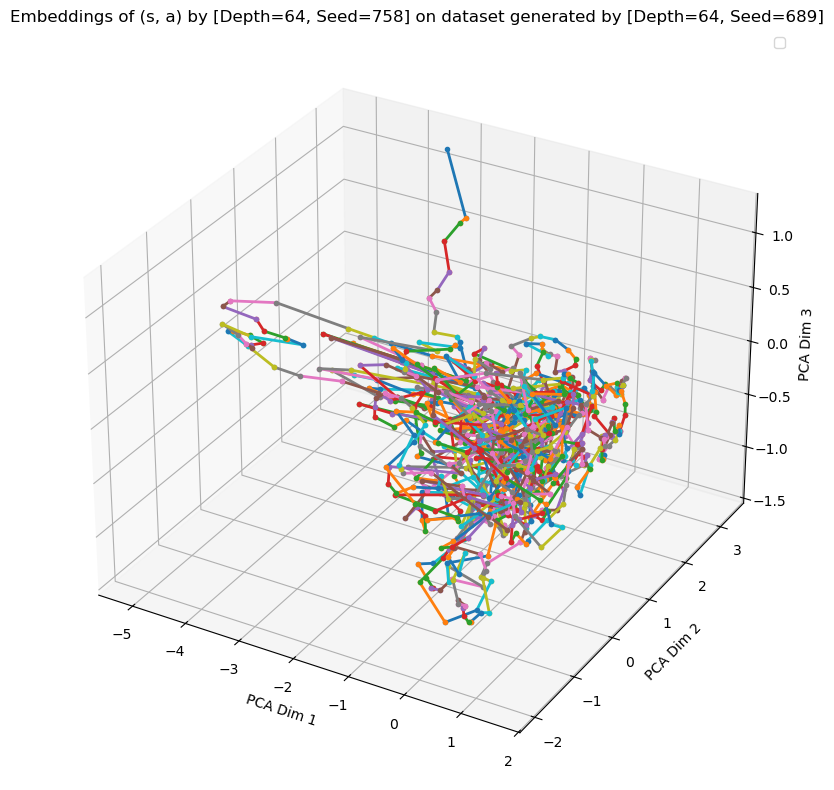

In [17]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051" #depth 64
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
sa_embeddings(model_dir, dataset_fname)

making env with env_id: humanoid


/tmp/ipykernel_421772/3458206093.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_421772/3458206093.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


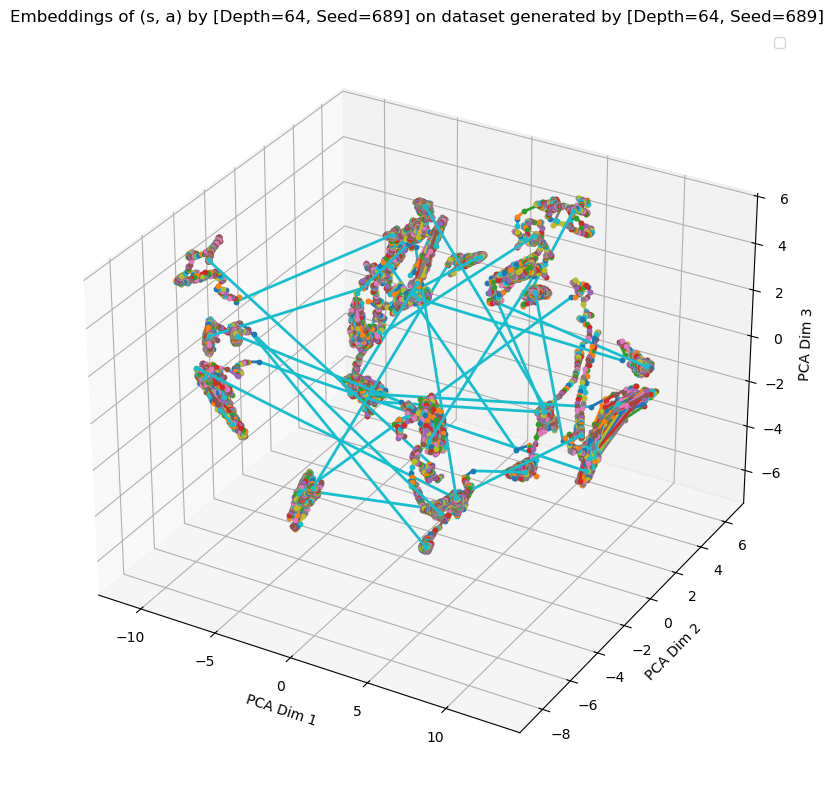

In [24]:
model_dir = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410" #depth 64
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
encodings = sa_embeddings(model_dir, dataset_fname)

In [25]:
encodings.shape

(30000, 64)

In [26]:
encodings

array([[ 1.199908  , -0.18332624,  0.13294283, ...,  0.18157649,
         0.18800624,  0.19303298],
       [ 1.1956321 , -0.19113724,  0.13733391, ...,  0.18800907,
         0.19420692,  0.19988146],
       [ 1.2137885 , -0.19119234,  0.14144465, ...,  0.19191226,
         0.19927302,  0.20310417],
       ...,
       [-0.60792065,  0.34319523, -0.21296935, ..., -0.31509185,
        -0.29028606, -0.3101573 ],
       [-0.66707623,  0.34346274, -0.2088787 , ..., -0.31345093,
        -0.28863883, -0.30713934],
       [-0.6897456 ,  0.34451738, -0.20699576, ..., -0.31332323,
        -0.28843954, -0.30650556]], dtype=float32)

In [31]:
import numpy as np

def sliced_wasserstein_distance(
    encodings: np.ndarray,
    n_projections: int = 1_000,
    assume_unit_norm: bool = False,
    seed: int | None = None,
    eps: float = 1e-8,
):
    """
    Parameters
    ----------
    encodings : (N, d) ndarray
        The representation matrix.
    n_projections : int
        Number of random directions to slice along (↑ → lower variance).
    assume_unit_norm : bool
        If True, encodings are L2‑normalised; we rescale by sqrt(d).
    seed : int | None
        RNG seed for reproducibility.
    eps : float
        Small value to avoid division by zero.

    Returns
    -------
    swd : float
        The (root‑mean‑square) 2‑Sliced‑Wasserstein distance to 𝒩(0,I).
    """
    rng = np.random.default_rng(seed)
    X = encodings.astype(np.float64, copy=True)
    N, d = X.shape

    # 1. Undo sphere normalisation if requested
    if assume_unit_norm:
        X *= np.sqrt(d)

    # 2. Whiten: zero mean, unit variance per coordinate
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True) + eps
    X = (X - mu) / sigma

    # 3. Generate random directions (unit vectors on S^{d‑1})
    dirs = rng.normal(size=(n_projections, d))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    # 4. Project encodings and a reference Gaussian onto each direction
    X_proj = X @ dirs.T                      # shape (N, M)
    Z_proj = rng.standard_normal(size=X_proj.shape)  # N samples from N(0,1)

    # 5. 1‑D 2‑Wasserstein distance per slice: E[(F^{-1}_X - F^{-1}_Z)^2]
    #    Empirically: sort both sets and take mean‑squared difference
    X_sorted = np.sort(X_proj, axis=0)
    Z_sorted = np.sort(Z_proj, axis=0)
    w2_per_slice = np.mean((X_sorted - Z_sorted) ** 2, axis=0)  # length M

    # 6. Aggregate over slices
    swd = np.sqrt(np.mean(w2_per_slice))
    return swd


import numpy as np

def estimate_gaussian_swd_floor(
    n_samples: int = 30_000,
    d: int = 64,
    n_projections: int = 1_024,
    trials: int = 30,
    seed: int | None = None,
):
    """
    Returns
    -------
    mean_floor : float
        Mean SWD between two independent N(0, I) samples of size `n_samples`.
    std_floor : float
        Sample standard deviation across `trials` Monte‑Carlo repeats.
    all_vals : ndarray
        Raw SWD values of shape (trials,).
    """
    rng = np.random.default_rng(seed)
    swd_vals = np.empty(trials, dtype=np.float64)

    for t in range(trials):
        # Two independent Gaussian batches
        g1 = rng.standard_normal(size=(n_samples, d))
        g2 = rng.standard_normal(size=(n_samples, d))

        # We can skip whitening because they’re already N(0,I),
        # but calling the same routine keeps pipeline identical.
        swd_vals[t] = sliced_wasserstein_distance(
            g1,
            n_projections=n_projections,
            assume_unit_norm=False,  # the Gaussians are not L2‑normalised
            seed=rng.integers(2**32),  # new seed for each trial’s projections
        )
        # Note: sliced_wasserstein_distance internally draws a fresh
        # reference Gaussian; here we want g1 vs g2, so we could
        # write a tiny wrapper that accepts both batches. A quick hack:
        # concatenate g1 and g2, label half as 'enc', half as 'ref',
        # and manually project. For simplicity we reuse the routine.

    return swd_vals.mean(), swd_vals.std(ddof=1), swd_vals

In [30]:
swd = sliced_wasserstein_distance(
        encodings,
        n_projections=1024,
        assume_unit_norm=True,   # set False if they’re *not* L2‑normalised
        seed=42
)
print(f"Sliced‑Wasserstein distance to N(0,I): {swd:.4f}")

Sliced‑Wasserstein distance to N(0,I): 0.5158


In [33]:
# Representation vs. Gaussian target
swd_repr = sliced_wasserstein_distance(
    encodings,
    n_projections=1024,
    assume_unit_norm=True,   # or False if you skipped ℓ₂ normalisation
    seed=42
)
print(f"SWD(encodings ∥ N(0,I)) = {swd_repr:.4f}")

# Finite‑sample “noise floor”
mean_floor, std_floor, _ = estimate_gaussian_swd_floor(
    n_samples=encodings.shape[0],
    d=encodings.shape[1],
    n_projections=1024,
    trials=30,
    seed=123
)
print(f"Expected SWD(Gauss ∥ Gauss) = {mean_floor:.4f} ± {std_floor:.4f} (1 σ)")
print(f"Gap above floor             = {swd_repr - mean_floor:.4f}")


SWD(encodings ∥ N(0,I)) = 0.5158
Expected SWD(Gauss ∥ Gauss) = 0.0142 ± 0.0001 (1 σ)
Gap above floor             = 0.5016


In [40]:
dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"

model_dirs = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659", #depth 4
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_271_20250117-071637", #depth 8
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_594_20250117-065555", #depth 16
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_186_20250105-180537", #depth 32
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051", #depth 64 (off policy)
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410", #depth 64 (on policy)
]

swds = []
for model_dir in model_dirs:
    encodings, (dataset_depth, dataset_seed, model_depth, model_seed) = sa_embeddings(model_dir, dataset_fname, plot=False)
    swd = sliced_wasserstein_distance(
        encodings,
        n_projections=1024,
        assume_unit_norm=False,   # set False if they’re *not* L2‑normalised
        seed=42
    )
    print(f"Sliced‑Wasserstein distance to N(0,I): {swd:.4f}")
    swds.append((swd, (dataset_depth, dataset_seed, model_depth, model_seed)))

making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.3752
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4332
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4628
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4022
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4696
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.5158


In [ ]:
for s in swds:
    swd, (dataset_depth, dataset_seed, model_depth, model_seed) = s
    

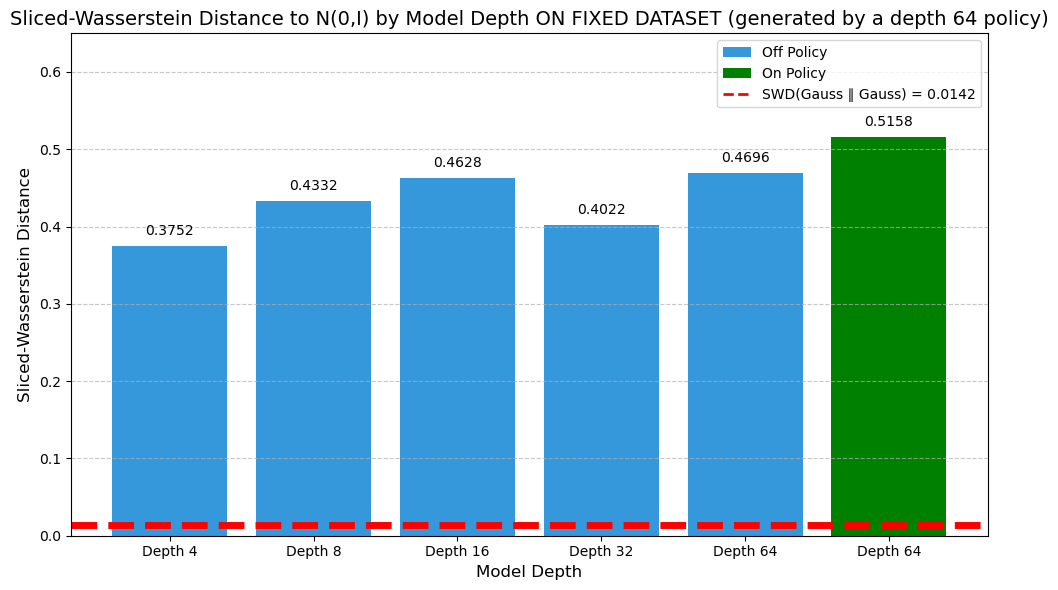

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your code
model_depths = [4, 8, 16, 32, 64, 64]
model_types = ["off policy" if i != 5 else "on policy" for i in range(6)]
# Replace these values with your actual SWD values
# Since I don't have the actual SWD values from your run, I'm using placeholders
# You should replace these with the actual values from your swds list
swd_values = [s[0] for s in swds]  # Placeholder values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.8

# Set positions of bars on x-axis
bar_positions = np.arange(len(model_depths))

# Create color scheme - different color for on-policy vs off-policy
colors = ['#3498db' if model_type == "off policy" else 'green' 
          for model_type in model_types]

# Create bars
bars = ax.bar(bar_positions, swd_values, width=bar_width, color=colors)

# Create x-axis labels
x_labels = [f"Depth {depth}" for i, depth in enumerate(model_depths)]
ax.set_xticks(bar_positions)
ax.set_xticklabels(x_labels)

# Add labels and title
ax.set_xlabel('Model Depth', fontsize=12)
ax.set_ylabel('Sliced-Wasserstein Distance', fontsize=12)
ax.set_title('Sliced-Wasserstein Distance to N(0,I) by Model Depth ON FIXED DATASET (generated by a depth 64 policy)', fontsize=14)
ax.set_ylim(None, 0.65)

# Add a horizontal grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add reference line for SWD(Gauss ∥ Gauss)
reference_value = 0.0142
ax.axhline(y=reference_value, color='red', linestyle='--', linewidth=5)

# Add a legend with reference line included
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#3498db', label='Off Policy'),
    Patch(facecolor='green', label='On Policy'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='SWD(Gauss ∥ Gauss) = 0.0142')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add value labels on top of each bar
for bar, value in zip(bars, swd_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# If you want to save the figure
# plt.savefig("swd_barplot.png", dpi=300, bbox_inches='tight')

In [75]:
#NOW SWD ON POLICY
# dataset_fname = "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"

model_dirs = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_671_20250105-181659", #depth 4
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_271_20250117-071637", #depth 8
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_594_20250117-065555", #depth 16
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_186_20250105-180537", #depth 32
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_758_20250105-190051", #depth 64 (off policy)
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/runs/humanoid_689_20250117-061410", #depth 64 (on policy)
]

dataset_fnames = [
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:4_seed:671_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:8_seed:271_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:16_seed:594_30000",
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:32_seed:186_30000",
    # "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:758_30000"
    "/scratch/gpfs/kw6487/JaxGCRL/clean_JaxGCRL/trajs_datasets/trajs_dataset_depth:64_seed:689_30000"
]


swds = []
for model_dir, dataset_fname in zip(model_dirs, dataset_fnames):
    encodings, (dataset_depth, dataset_seed, model_depth, model_seed) = sa_embeddings(model_dir, dataset_fname, plot=False)
    swd = sliced_wasserstein_distance(
        encodings,
        n_projections=1024,
        assume_unit_norm=False,   # set False if they’re *not* L2‑normalised
        seed=42
    )
    print(f"Sliced‑Wasserstein distance to N(0,I): {swd:.4f}")
    swds.append((swd, (dataset_depth, dataset_seed, model_depth, model_seed)))

making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.3443
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4240
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.4553
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.3952
making env with env_id: humanoid
Sliced‑Wasserstein distance to N(0,I): 0.5158


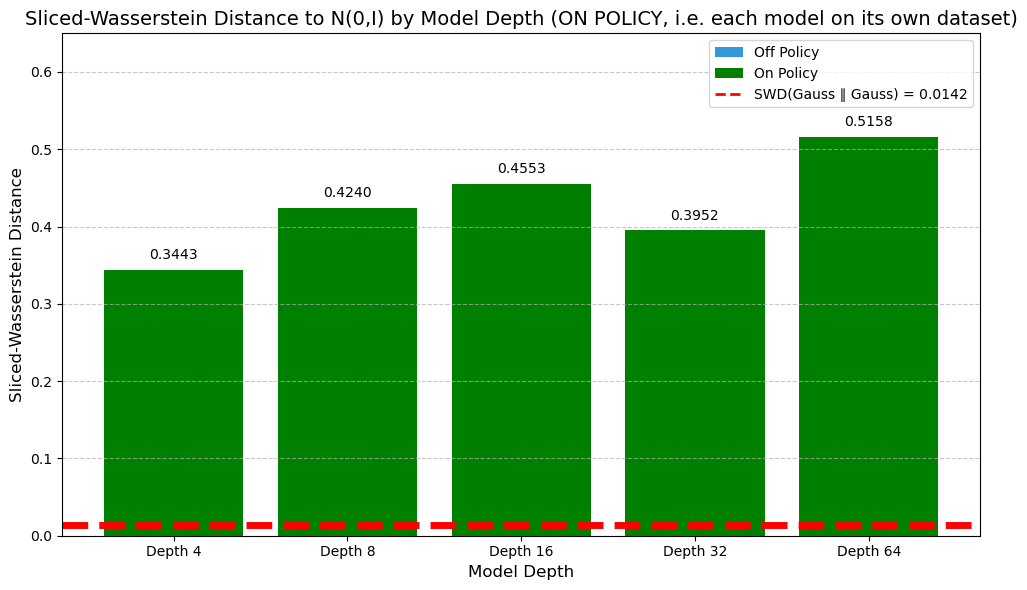

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your code
model_depths = [4, 8, 16, 32, 64]
model_types = ["on policy" for i in range(5)]
# Replace these values with your actual SWD values
# Since I don't have the actual SWD values from your run, I'm using placeholders
# You should replace these with the actual values from your swds list
swd_values = [s[0] for s in swds]  # Placeholder values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Set bar width
bar_width = 0.8

# Set positions of bars on x-axis
bar_positions = np.arange(len(model_depths))

# Create color scheme - different color for on-policy vs off-policy
colors = ['#3498db' if model_type == "off policy" else 'green' 
          for model_type in model_types]

# Create bars
bars = ax.bar(bar_positions, swd_values, width=bar_width, color=colors)

# Create x-axis labels
x_labels = [f"Depth {depth}" for i, depth in enumerate(model_depths)]
ax.set_xticks(bar_positions)
ax.set_xticklabels(x_labels)

# Add labels and title
ax.set_xlabel('Model Depth', fontsize=12)
ax.set_ylabel('Sliced-Wasserstein Distance', fontsize=12)
ax.set_title('Sliced-Wasserstein Distance to N(0,I) by Model Depth (ON POLICY, i.e. each model on its own dataset)', fontsize=14)
ax.set_ylim(None, 0.65)

# Add a horizontal grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Add reference line for SWD(Gauss ∥ Gauss)
reference_value = 0.0142
ax.axhline(y=reference_value, color='red', linestyle='--', linewidth=5)

# Add a legend with reference line included
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#3498db', label='Off Policy'),
    Patch(facecolor='green', label='On Policy'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='SWD(Gauss ∥ Gauss) = 0.0142')
]
ax.legend(handles=legend_elements, loc='upper right')

# Add value labels on top of each bar
for bar, value in zip(bars, swd_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# If you want to save the figure
# plt.savefig("swd_barplot.png", dpi=300, bbox_inches='tight')

In [4]:
states = states_dataset

NameError: name 'args' is not defined

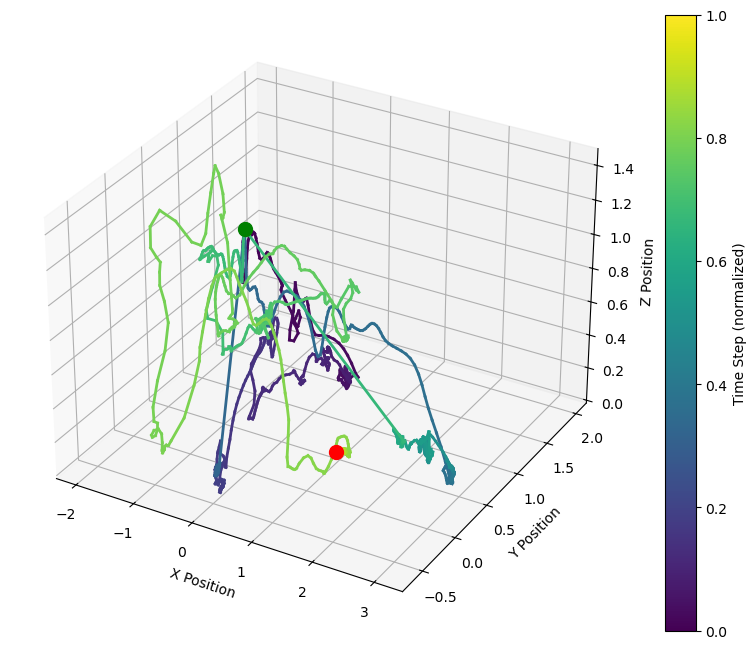

In [5]:
# Create a color map based on time steps
states_np = np.array(states)

positions = states_np[0:3000, :3]  # Assuming first 3 values are x, y, z positions

time_steps = np.linspace(0, 1, len(positions))
cm = plt.cm.viridis

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory with color gradient
for i in range(len(positions) - 1):
    ax.plot(positions[i:i+2, 0], positions[i:i+2, 1], positions[i:i+2, 2], 
            color=cm(time_steps[i]), linewidth=2)

# Mark start and end positions
ax.scatter(positions[0, 0], positions[0, 1], positions[0, 2], c='g', s=100, label='Start')
ax.scatter(positions[-1, 0], positions[-1, 1], positions[-1, 2], c='r', s=100, label='End')

# Add a colorbar to show time progression
sm = plt.cm.ScalarMappable(cmap=cm)
sm.set_array(time_steps)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Time Step (normalized)')

# Add labels and title
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_zlabel('Z Position')
ax.set_title(f'3D Trajectory of Humanoid Agent (DEPTH {args.actor_depth})')
ax.legend()

plt.tight_layout()
plt.show()